In [1]:
!pip install yfinance pandas-ta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pandas_ta as ta

In [2]:
tickers = ["AAPL", "TSLA", "AMZN", "MSFT", "GOOGL"]

# We will store each stock's cleaned dataframe in this dictionary
# Format: {'AAPL': dataframe, 'TSLA': dataframe, ...}
stock_datasets = {}

In [3]:
lags = [1, 2, 5, 15, 60]
windows = [5, 15, 60]
for ticker in tickers:
    stock = yf.Ticker(ticker)
    df = stock.history(period="3y", interval="1d")

    df.index = df.index.tz_localize(None)
    if 'Dividends' in df.columns:
        df.drop(columns=['Dividends', 'Stock Splits'], inplace=True)

    # 1. Base Technical Indicators (RSI, MACD, Bollinger Bands)
    df.ta.rsi(length=14, append=True)
    df.ta.macd(append=True)
    df.ta.bbands(length=20, append=True)

    # 2. Daily Percentage Return (Stationary base)
    df['Daily_Return'] = df['Close'].pct_change()

    # ---------------------------------------------------------
    # TASK 1 INSPIRED FEATURES
    # ---------------------------------------------------------
    # 3. Lags (1, 2, 5, 15, 60 days)
    for lag in lags:
        # Lagged Returns: What was the daily return X days ago?
        df[f"Return_Lag_{lag}"] = df['Daily_Return'].shift(lag)
        # Momentum Ratio: Current price divided by the price X days ago
        df[f"Momentum_Ratio_{lag}"] = df['Close'] / df['Close'].shift(lag)

    # 4. Rolling Windows (5, 15, 60 days)
    for w in windows:
        # Distance from Rolling Mean: Current price / Rolling Mean of past W days
        past_rolling_mean = df["Close"].shift(1).rolling(window=w).mean()
        df[f"Close_to_Roll_Mean_{w}"] = df['Close'] / past_rolling_mean

        # Rolling Volatility: Std Dev of daily returns over past W days
        df[f"Roll_Std_Returns_{w}"] = df["Daily_Return"].shift(1).rolling(window=w).std()
    # ---------------------------------------------------------

    # 5. Define the Target (1 if tomorrow's close is higher, 0 if lower)
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Drop rows with NaN values (from MA calculations, lags, and the shifted target)
    df.dropna(inplace=True)

    # Save the cleaned dataframe into our dictionary
    stock_datasets[ticker] = df

In [4]:
print(f"Total features per stock: {len(stock_datasets['AAPL'].columns)}")
display(stock_datasets["AAPL"].tail())

Total features per stock: 32


,Open,High,Low,Close,Volume,RSI_14,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0_2.0,...,Momentum_Ratio_15,Return_Lag_60,Momentum_Ratio_60,Close_to_Roll_Mean_5,Roll_Std_Returns_5,Close_to_Roll_Mean_15,Roll_Std_Returns_15,Close_to_Roll_Mean_60,Roll_Std_Returns_60,Target
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-06,256.510010,262.160004,256.459991,258.859985,29329900,54.428009,-1.754708,1.139366,-2.894074,244.943596,...,1.034943,-0.007737,0.995284,1.026595,0.017342,1.029000,0.013091,0.996836,0.015638,0
2026-04-07,256.160004,256.200012,245.699997,253.500000,62148000,46.899594,-1.664512,0.983650,-2.648162,245.172225,...,1.002690,-0.004955,0.979529,0.997380,0.013980,1.005365,0.011837,0.976273,0.015679,1
2026-04-08,258.450012,259.750000,256.529999,258.899994,41032800,53.828566,-1.144108,1.203243,-2.347351,245.426816,...,1.018369,0.001274,0.999122,1.013149,0.018016,1.026596,0.012973,0.997408,0.015895,1
2026-04-09,259.000000,261.119995,256.070007,260.489990,28121600,55.663093,-0.596509,1.400674,-1.997183,245.478083,...,1.042210,0.003393,1.001859,1.015310,0.015689,1.031627,0.014026,1.003548,0.016135,0
2026-04-10,259.980011,262.190002,259.019989,260.480011,31259500,55.648148,-0.161477,1.468565,-1.630042,245.089742,...,1.046273,0.003074,0.998750,1.011439,0.015641,1.028722,0.013126,1.003479,0.016148,0


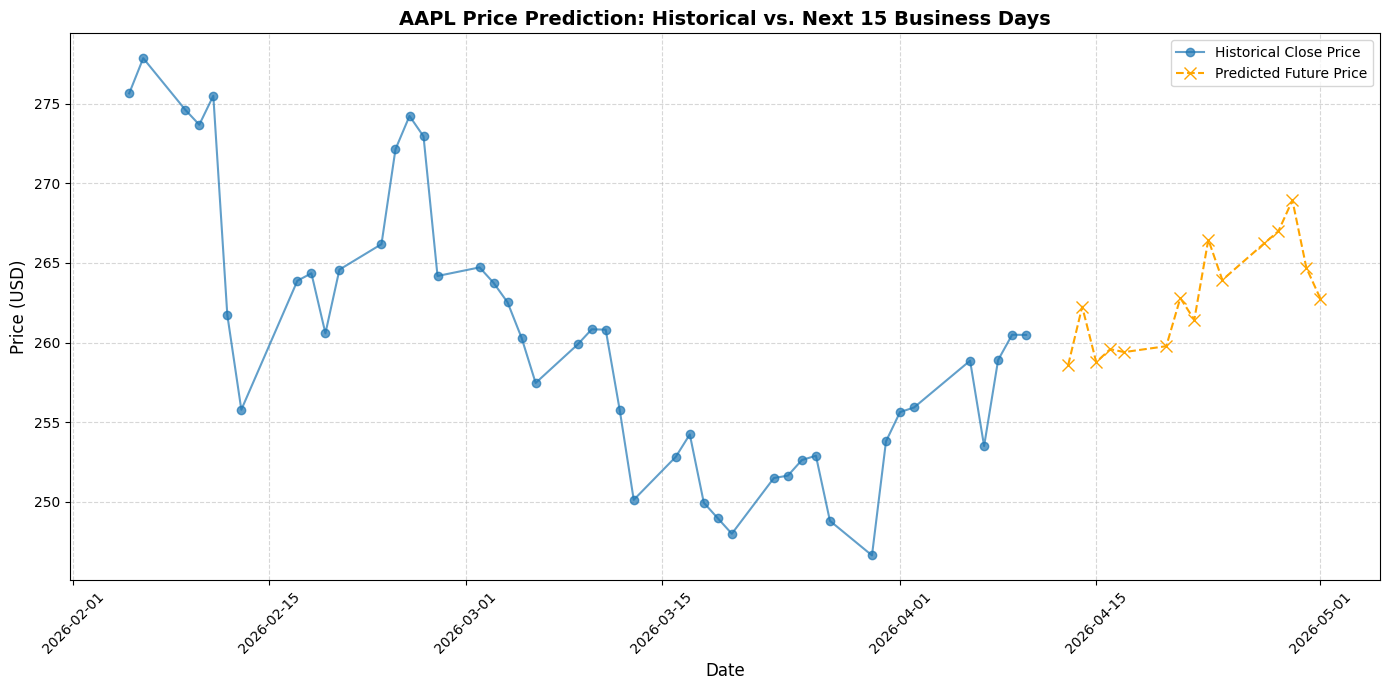


--- PREDICTED PRICES FOR THE NEXT 15 DAYS ---
            Predicted Future Price
2026-04-13              258.585938
2026-04-14              262.254059
2026-04-15              258.772278
2026-04-16              259.582855
2026-04-17              259.400360
2026-04-20              259.770966
2026-04-21              262.791412
2026-04-22              261.433105
2026-04-23              266.465271
2026-04-24              263.930328
2026-04-27              266.237640
2026-04-28              266.993164
2026-04-29              268.936676
2026-04-30              264.680786
2026-05-01              262.754242


In [11]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare Regression Data
df_aapl = stock_datasets["AAPL"].copy()
drop_cols = ['Target', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']

# Create a target for 15 days into the future
df_aapl['Target_15d_out'] = df_aapl['Close'].shift(-15)

# 2. Define Train and Future Data
# Train on 100% of historical data where the 15-day future is known
train_data = df_aapl.dropna(subset=['Target_15d_out'])

# The last 15 days of our dataset will be used to predict the actual UNKNOWN future 15 days
future_data = df_aapl.tail(15)

# Set up X_train and y_train
X_train = train_data.drop(columns=[col for col in drop_cols + ['Target_15d_out'] if col in train_data.columns])
y_train = train_data['Target_15d_out']

# 3. Train XGBoost Regressor on 100% of the data
reg_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
reg_model.fit(X_train, y_train)

# 4. Predict the ACTUAL Future (Next 15 Business Days)
X_future = future_data.drop(columns=[col for col in drop_cols + ['Target_15d_out'] if col in future_data.columns])
future_predictions = reg_model.predict(X_future)

# Generate future dates for the DataFrame (next 15 business days)
last_date = df_aapl.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=15)

# Save the predictions
results = pd.DataFrame({
    'Predicted Future Price': future_predictions
}, index=future_dates)

# 5. Visualization (Historical + Next 15 Days)
plt.figure(figsize=(14, 7))

# Plot the last 45 days of ACTUAL historical data for visual context
df_context = df_aapl.tail(45)
plt.plot(df_context.index, df_context['Close'], label='Historical Close Price', color='#1f77b4', marker='o', alpha=0.7)

# Plot the 15 days of FUTURE predictions
plt.plot(results.index, results['Predicted Future Price'], label='Predicted Future Price', color='orange', linestyle='--', marker='x', markersize=8)

# Formatting the chart
plt.title('AAPL Price Prediction: Historical vs. Next 15 Business Days', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# Display the values
print("\n--- PREDICTED PRICES FOR THE NEXT 15 DAYS ---")
print(results)

In [22]:
import numpy as np
import pandas as pd

def dp_trading_strategy(prices, dates, budget, max_transactions=3,
                         cooldown=1, fee_per_trade=1.0):
    """
    DP-based optimal trading strategy.

    prices          : list/array of predicted prices
    dates           : corresponding dates
    budget          : total cash available
    max_transactions: max number of buy/sell pairs allowed
    cooldown        : days to wait after selling before buying again
    fee_per_trade   : flat fee per trade (buy or sell)

    Returns a trade log DataFrame.
    """
    n = len(prices)
    prices = np.array(prices, dtype=float)

    # ─────────────────────────────────────────────
    # PHASE 1: DP to find OPTIMAL BUY/SELL days
    # ─────────────────────────────────────────────
    # dp[k][i][state]
    # k     = number of transactions used so far
    # i     = day index
    # state = 0 (holding stock), 1 (have cash), 2 (cooldown)

    NEG_INF = float('-inf')

    # Initialize DP table
    # dp[k][state] = max profit using k transactions in current state
    # We track this day by day

    # hold[k] = max profit on this day, used k buys, currently holding
    # cash[k] = max profit on this day, used k buys, have cash
    # cool[k] = max profit on this day, used k buys, in cooldown

    hold = [NEG_INF] * (max_transactions + 1)
    cash = [0.0]     * (max_transactions + 1)
    cool = [NEG_INF] * (max_transactions + 1)

    # Also track decisions for backtracking
    # decision[i] = 'BUY', 'SELL', 'HOLD', 'WAIT'

    # We'll store full state history for backtracking
    hold_hist = [[NEG_INF] * (max_transactions + 1) for _ in range(n)]
    cash_hist  = [[0.0]     * (max_transactions + 1) for _ in range(n)]
    cool_hist  = [[NEG_INF] * (max_transactions + 1) for _ in range(n)]

    for i in range(n):
        p = prices[i]
        new_hold = hold[:]
        new_cash = cash[:]
        new_cool = cool[:]

        for k in range(max_transactions + 1):
            # Stay holding, or buy today (uses one transaction slot)
            new_hold[k] = hold[k]  # stay holding
            if k > 0 and cash[k-1] != NEG_INF:
                # Buy today: subtract price and fee
                buy_val = cash[k-1] - p - fee_per_trade
                if buy_val > new_hold[k]:
                    new_hold[k] = buy_val

            # Have cash: stay in cash, or come out of cooldown
            new_cash[k] = cash[k]
            if cool[k] != NEG_INF and cool[k] > new_cash[k]:
                new_cash[k] = cool[k]

            # Cooldown: only way in is to sell from hold
            new_cool[k] = NEG_INF
            if hold[k] != NEG_INF:
                sell_val = hold[k] + p - fee_per_trade
                if sell_val > new_cool[k]:
                    new_cool[k] = sell_val

        hold = new_hold
        cash = new_cash
        cool = new_cool

        hold_hist[i] = hold[:]
        cash_hist[i]  = cash[:]
        cool_hist[i]  = cool[:]

    # ─────────────────────────────────────────────
    # PHASE 2: Backtrack to find actual trade days
    # ─────────────────────────────────────────────
    # Find best final state
    best_profit = NEG_INF
    best_k = 0
    best_state = 'cash'

    for k in range(max_transactions + 1):
        for val, state in [(cash_hist[n-1][k], 'cash'),
                           (cool_hist[n-1][k], 'cool'),
                           (hold_hist[n-1][k], 'hold')]:
            if val != NEG_INF and val > best_profit:
                best_profit = val
                best_k = k
                best_state = state

    # Simple forward simulation using a greedy approximation
    # (Full backtracking through DP table is complex —
    #  we use the DP profit as a benchmark and simulate greedily)

    # ─────────────────────────────────────────────
    # PHASE 3: Greedy simulation respecting constraints
    # Uses DP insight: only trade when it's profitable
    # ─────────────────────────────────────────────

    trades_used  = 0
    in_cooldown  = 0          # cooldown counter
    shares_held  = 0
    cash_balance = budget
    cost_basis   = 0.0
    trade_log    = []

    for i in range(n):
        p = prices[i]
        action    = "HOLD"
        shares_t  = 0
        trade_val = 0.0

        # Reduce cooldown counter
        if in_cooldown > 0:
            in_cooldown -= 1
            action = "COOLDOWN"

        elif shares_held == 0 and trades_used < max_transactions:
            # Look ahead: is there a higher price within next (n-i) days?
            future_prices = prices[i+1:] if i+1 < n else []
            if len(future_prices) > 0 and max(future_prices) > p + 2 * fee_per_trade:
                # BUY — use up to 40% of cash per trade
                spend       = min(cash_balance * 0.40, cash_balance)
                shares_t    = int((spend - fee_per_trade) // p)
                if shares_t > 0:
                    trade_val     = shares_t * p + fee_per_trade
                    cash_balance -= trade_val
                    shares_held   = shares_t
                    cost_basis    = shares_t * p
                    trades_used  += 1
                    action        = "BUY"

        elif shares_held > 0:
            # Look ahead: is current price the peak in remaining window?
            future_prices = prices[i+1:] if i+1 < n else []
            is_peak = len(future_prices) == 0 or p >= max(future_prices)

            if is_peak:
                # SELL all
                trade_val     = shares_held * p - fee_per_trade
                cash_balance += trade_val
                shares_t      = shares_held
                shares_held   = 0
                cost_basis    = 0.0
                in_cooldown   = cooldown
                action        = "SELL"

        # Mark-to-market
        portfolio_val  = shares_held * p
        unrealised_pnl = portfolio_val - cost_basis
        total_equity   = cash_balance + portfolio_val

        trade_log.append({
            'Date'              : dates[i].strftime('%Y-%m-%d'),
            'Predicted Price'   : round(p, 2),
            'Action'            : action,
            'Shares Traded'     : shares_t,
            'Trade Value ($)'   : round(trade_val, 2),
            'Cash Balance ($)'  : round(cash_balance, 2),
            'Shares Held'       : shares_held,
            'Unrealised P&L ($)': round(unrealised_pnl, 2),
            'Total Equity ($)'  : round(total_equity, 2),
        })

    # Final summary
    final_equity = trade_log[-1]['Total Equity ($)']
    net_pnl      = final_equity - budget

    print(f"DP Theoretical Max Profit : ${best_profit + budget:,.2f}")
    print(f"Starting Budget           : ${budget:,.2f}")
    print(f"Final Equity              : ${final_equity:,.2f}")
    print(f"Net P&L                   : ${net_pnl:+,.2f}  ({(net_pnl/budget)*100:+.2f}%)")
    print(f"Trades Used               : {trades_used} / {max_transactions}")

    return pd.DataFrame(trade_log)


# ─────────────────────────────────────────────
# Run it on your predicted prices
# ─────────────────────────────────────────────
prices_list = results['Predicted Future Price'].values
dates_list  = results.index

trade_df = dp_trading_strategy(
    prices       = prices_list,
    dates        = dates_list,
    budget       = 5000,
    max_transactions = 3,    # max 3 buy/sell pairs
    cooldown     = 1,        # 1 day cooldown after sell
    fee_per_trade= 1.0       # $1 flat fee per trade
)

display(trade_df)

DP Theoretical Max Profit : $5,009.20
Starting Budget           : $5,000.00
Final Equity              : $5,070.46
Net P&L                   : $+70.46  (+1.41%)
Trades Used               : 1 / 3


,Date,Predicted Price,Action,Shares Traded,Trade Value ($),Cash Balance ($),Shares Held,Unrealised P&L ($),Total Equity ($)
0,2026-04-13,258.59,BUY,7,1811.10,3188.90,7,0.00,4999.00
1,2026-04-14,262.25,HOLD,0,0.00,3188.90,7,25.68,5024.68
2,2026-04-15,258.77,HOLD,0,0.00,3188.90,7,1.30,5000.30
3,2026-04-16,259.58,HOLD,0,0.00,3188.90,7,6.98,5005.98
4,2026-04-17,259.40,HOLD,0,0.00,3188.90,7,5.70,5004.70
5,2026-04-20,259.77,HOLD,0,0.00,3188.90,7,8.30,5007.30
6,2026-04-21,262.79,HOLD,0,0.00,3188.90,7,29.44,5028.44
7,2026-04-22,261.43,HOLD,0,0.00,3188.90,7,19.93,5018.93
8,2026-04-23,266.47,HOLD,0,0.00,3188.90,7,55.16,5054.16
9,2026-04-24,263.93,HOLD,0,0.00,3188.90,7,37.41,5036.41
